In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

Matplotlib is building the font cache; this may take a moment.


In [3]:
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'Times'})

In [4]:
cache_path = './exported_imgs'
if not os.path.exists(cache_path):
    os.makedirs(cache_path)
def save_fig(fname):
    plt.tight_layout()
    out_file = os.path.join(cache_path, fname)
    print(f"save fig => {out_file}")
    plt.savefig(out_file)

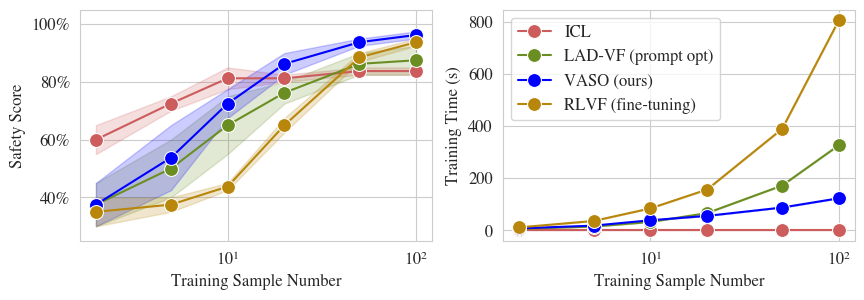

In [11]:
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('results/safe-score-data-size.csv')

df['Category'] = df['Category'].replace('In-Context', 'ICL')
df['Category'] = df['Category'].replace('Prompt Opt (LAD-VF)', 'LAD-VF (prompt opt)')
df['Category'] = df['Category'].replace('VASO (ours)', 'VASO (ours)')
df['Category'] = df['Category'].replace('Fine-tuning (RLVF)', 'RLVF (fine-tuning)')

fig, axs = plt.subplots(1,2, figsize=(10,3), sharex=True)

kwargs = dict(marker='o', markersize=10, palette=['#CD5C5C', '#6B8E23', 'blue', '#B8860B'])

ax = axs[0]
sns.lineplot(df, x='Training Sample Number', y='Safety Score', hue='Category', ax=ax, **kwargs)
ax.set_ylim(0.25, 1.05)
# ax.legend(loc="lower right", ncol = 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))  # format as percentages
ax.legend([],[], frameon=False)
plt.xscale('log')

ax = axs[1]
# ax = sns.lineplot(df, x='Training Sample Number',y='Training Time (s)',hue='Category', marker='o', linestyle='dashed')
sns.lineplot(df, x='Training Sample Number', y='Training Time (s)', hue='Category', ax=ax, **kwargs)
ax.legend(loc="upper left", ncol = 1)
plt.xscale('log')


# save_fig('sample-size-accuracy-n-time.pdf')

/var/folders/q1/9j_99jz15977r22jt0h3d3hh0000gp/T/ipykernel_44921/364620862.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


save fig => ./exported_imgs/sample-size-accuracy-n-time.pdf


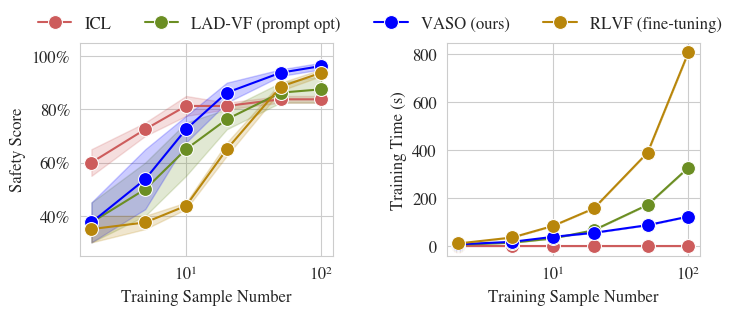

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharex=True, gridspec_kw={"wspace": 0.45})

kwargs = dict(marker="o", markersize=10, palette=["#CD5C5C", "#6B8E23", "blue", "#B8860B"])

sns.lineplot(df, x="Training Sample Number", y="Safety Score", hue="Category", ax=axs[0], **kwargs)
axs[0].set_ylim(0.25, 1.05)
axs[0].yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
axs[0].set_xscale("log")

sns.lineplot(df, x="Training Sample Number", y="Training Time (s)", hue="Category", ax=axs[1], **kwargs)
axs[1].set_xscale("log")

handles, labels = axs[0].get_legend_handles_labels()
for a in axs:
    a.legend_.remove()

fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.96), ncol=4, frameon=False)
fig.subplots_adjust(top=0.82, wspace=0.2)

save_fig('sample-size-accuracy-n-time.pdf')

save fig => ./exported_imgs/generalization.pdf


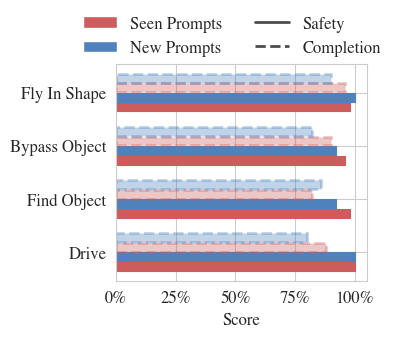

In [31]:
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

df = pd.read_csv("results/generalization.csv")

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 12, "font.family": "Times"})

category_colors = {
    "training": "#CD5C5C",
    "testing": "#4F81BD",
}
category_labels = {
    "training": "Seen Prompts",
    "testing": "New Prompts",
}

skill_order = ["drive", "find-object", "bypass-object", "fly-in-shape"]
bar_specs = [
    ("training", "safety"),
    ("testing", "safety"),
    ("training", "completion"),
    ("testing", "completion"),
]

df["skill"] = pd.Categorical(df["skill"], categories=skill_order, ordered=True)

n_skills = len(skill_order)
n_bars = len(bar_specs)
y_pos = np.arange(n_skills)
group_h = 0.72
bar_h = group_h / n_bars
offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * bar_h

fig, ax = plt.subplots(figsize=(4, 3))

for j, (cat, metric) in enumerate(bar_specs):
    for i, skill in enumerate(skill_order):
        score = float(
            df.loc[
                (df["skill"] == skill)
                & (df["category"] == cat)
                & (df["metric"] == metric),
                "score",
            ].iloc[0]
        )
        y = y_pos[i] + offsets[j]
        color = category_colors[cat]

        if metric == "safety":
            ax.barh(
                y, score, height=bar_h * 0.92,
                color=color, edgecolor=color,
                linewidth=0.8, linestyle="-",
            )
        else:
            ax.barh(
                y, score, height=bar_h * 0.92,
                facecolor=color, alpha=0.35,
                edgecolor=color, linewidth=2.0, linestyle="--",
            )

ax.set_yticks(y_pos)
ax.set_yticklabels([s.replace("-", " ").title() for s in skill_order])
ax.set_xlim(0, 1.05)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Score")

legend_handles = [
    Patch(facecolor=category_colors["training"], label=category_labels["training"]),
    Patch(facecolor=category_colors["testing"], label=category_labels["testing"]),
    Line2D([0], [0], color="0.3", linewidth=2, linestyle="-", label="Safety"),
    Line2D([0], [0], color="0.3", linewidth=2, linestyle="--", label="Completion"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.6, 1.15),
    ncol=2,
    frameon=False,
)
fig.subplots_adjust(top=0.82)

plt.tight_layout()
save_fig("generalization.pdf")

/Library/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


save fig => ./exported_imgs/sample-size-accuracy-n-time.pdf


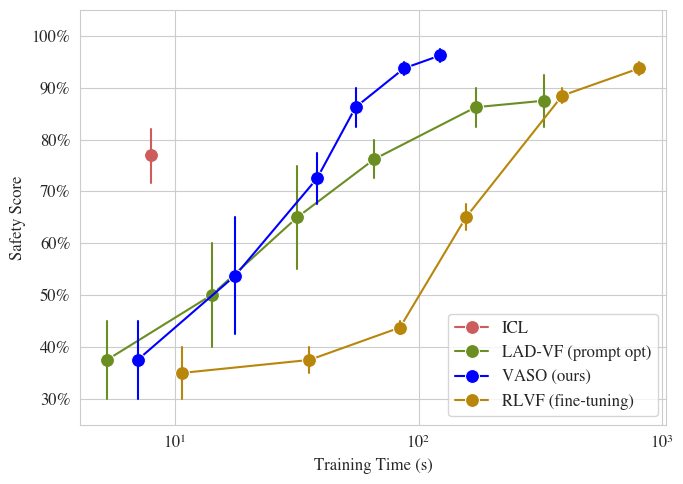

In [5]:
df = pd.read_csv('results/safe-score-data-size.csv')

df['Category'] = df['Category'].replace('In-Context', 'ICL')
df['Category'] = df['Category'].replace('Prompt Opt (LAD-VF)', 'LAD-VF (prompt opt)')
df['Category'] = df['Category'].replace('VASO (ours)', 'VASO (ours)')
df['Category'] = df['Category'].replace('Fine-tuning (RLVF)', 'RLVF (fine-tuning)')

df.loc[df['Category'] == 'ICL', 'Training Time (s)'] = 8

plt.figure(figsize=(7,5))

kwargs = dict(marker='o', markersize=10,
              palette=['#CD5C5C', '#6B8E23', 'blue', '#B8860B'])

sns.lineplot(
    df,
    x='Training Time (s)',
    y='Safety Score',
    hue='Category',
    err_style='bars',
    **kwargs
)

plt.xscale('log')  # optional, but usually still useful
plt.ylim(0.25, 1.05)
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

plt.legend(loc="lower right")
plt.xlabel("Training Time (s)")
plt.ylabel("Safety Score")

plt.tight_layout()
# plt.show()

save_fig('sample-size-accuracy-n-time.pdf')

save fig => ./exported_imgs/safety_optimization_step.pdf


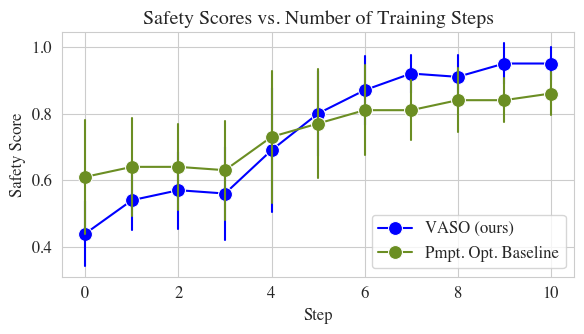

In [4]:
df = pd.read_csv('results/safe-score-step.csv')

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'Times'})

fig, ax = plt.subplots(1,1, figsize=(6,3.5))

kwargs = dict(marker='o', markersize=10, palette=['blue', '#6B8E23'])

ax = sns.lineplot(df, x='Step',y='Safety Score',hue='Category', errorbar='sd', err_style='bars', **kwargs)
ax.set_title('Safety Scores vs. Number of Training Steps')
ax.legend(loc="lower right", ncol = 1)

save_fig('safety_optimization_step.pdf')

save fig => ./exported_imgs/testing_scores.pdf


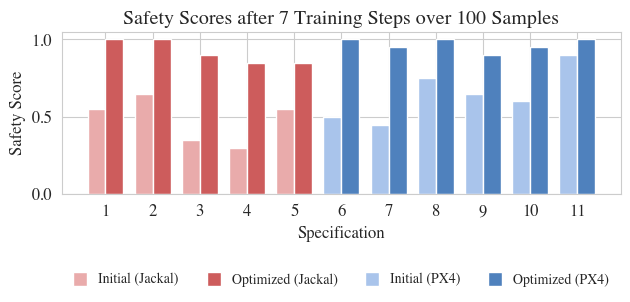

In [7]:
df = pd.read_csv('results/safety-testing.csv')

fig, ax = plt.subplots(1,1, figsize=(6.5,3))

df['Category'] = df['Category'].replace('Step 0', 'Initial Prompt')
df['Category'] = df['Category'].replace('Step 7', 'Final Prompt')
df["Safety Score"] = df["Number of Satisfied Samples"] / 20

# Pivot for easier plotting
plot_df = df.pivot(
    index="Specification",
    columns="Category",
    values="Safety Score"
).sort_index()

x = np.arange(len(plot_df.index))
width = 0.38

# Colors:
# spec 1–10
init_color_1 = "#E9ABAB"
final_color_1 = "#CD5C5C"

# spec 11–15
init_color_2 = "#A9C4EB"
final_color_2 = "#4F81BD"

# Assign colors by specification group
init_colors = [init_color_1 if spec <= 5 else init_color_2 for spec in plot_df.index]
final_colors = [final_color_1 if spec <= 5 else final_color_2 for spec in plot_df.index]

# Draw bars
bars1 = ax.bar(
    x - width/2,
    plot_df["Initial Prompt"],
    width,
    color=init_colors,
    label="Initial Prompt"
)

bars2 = ax.bar(
    x + width/2,
    plot_df["Final Prompt"],
    width,
    color=final_colors,
    label="Final Prompt"
)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_xlabel("Specification")
ax.set_ylabel("Safety Score")
ax.set_title("Safety Scores after 7 Training Steps over 100 Samples")
ax.legend(title="")

# --- Custom legend (4 entries) ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E9ABAB", label="Initial (Jackal)"),
    Patch(facecolor="#CD5C5C", label="Optimized (Jackal)"),
    Patch(facecolor="#A9C4EB", label="Initial (PX4)"),
    Patch(facecolor="#4F81BD", label="Optimized (PX4)")
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.4),  # push below plot
    ncol=4,
    handlelength=1,
    handleheight=1.2,
    fontsize=10,
    frameon=False
)

plt.tight_layout()

save_fig('testing_scores.pdf')